# TuSimple Lane Detection — YOLO11 Instance Segmentation

End-to-end: download → convert TuSimple polylines to YOLO-seg polygons →
train → evaluate → visualize.

**Runtime:** set to GPU (Runtime → Change runtime type → T4 GPU).

Labels are generated in a **single pass** from the raw TuSimple annotations.
Do not add a second "widen the polygons" pass — the polygon files are closed
outlines, not centerlines, and re-thickening them produces self-intersecting
masks. To change lane thickness, edit `HALF_WIDTH_BASE` / `HALF_WIDTH_GROW`
below and re-run the conversion.

In [1]:
!pip install -q ultralytics kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 7.7 MB/s eta 0:00:00


In [2]:
import torch
from ultralytics import YOLO

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU. Runtime -> Change runtime type -> T4 GPU")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
CUDA: True
GPU: Tesla T4


## 1. Mount Drive

Training writes straight to Drive so a Colab disconnect doesn't cost the run.
If you'd rather not use Drive, set `PROJECT_DIR = "/content/lane_detection"`
and accept that a disconnect loses the weights.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/lane_detection"
RUN_NAME = "yolo11s_tusimple"

Mounted at /content/drive


## 2. Download the dataset

In [4]:
import kagglehub

dataset_path = kagglehub.dataset_download("manideep1108/tusimple")
print("Downloaded to:", dataset_path)

100%|██████████| 21.6G/21.6G [09:24<00:00, 41.1MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/manideep1108/tusimple/versions/5


In [5]:
import glob

SEARCH_PATH = dataset_path

json_files = sorted(glob.glob(SEARCH_PATH + "/**/label_data*.json", recursive=True))

print("Annotation files found:", len(json_files))
for f in json_files:
    print(" ", f)

assert json_files, "No label_data*.json found — check the download path."

Annotation files found: 3
  /root/.cache/kagglehub/datasets/manideep1108/tusimple/versions/5/TUSimple/train_set/label_data_0313.json
  /root/.cache/kagglehub/datasets/manideep1108/tusimple/versions/5/TUSimple/train_set/label_data_0531.json
  /root/.cache/kagglehub/datasets/manideep1108/tusimple/versions/5/TUSimple/train_set/label_data_0601.json


## 3. Build the record list

TuSimple annotations are JSON Lines: one object per frame, with `raw_file`
relative to the directory holding the annotation file. Each labelled clip
contributes exactly one frame (`20.jpg`), so ~3,626 records total.

In [6]:
import json
import os

records = []
missing = 0

for json_file in json_files:
    annotation_root = os.path.dirname(json_file)

    with open(json_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            data = json.loads(line)
            image_path = os.path.join(annotation_root, data["raw_file"])

            if os.path.exists(image_path):
                records.append(
                    {
                        "image": image_path,
                        "lanes": data["lanes"],
                        "h_samples": data["h_samples"],
                    }
                )
            else:
                missing += 1

print("Valid records:", len(records))
print("Missing images:", missing)

Valid records: 3626
Missing images: 0


## 4. Train / val split

Each record is a distinct clip, so a random frame-level split does not leak
neighbouring frames of the same video between train and val.

In [7]:
import random

random.seed(42)
random.shuffle(records)

split = int(len(records) * 0.8)
train_records = records[:split]
val_records = records[split:]

print("Train:", len(train_records))
print("Val:  ", len(val_records))

Train: 2900
Val:   726


## 5. Centerline → polygon

TuSimple gives a lane as a polyline (a centerline). YOLO segmentation needs a
closed polygon, so each centerline is offset along its normal by `half_width`
on both sides and the two offset curves are joined into one ring.

`half_width` grows toward the bottom of the frame because lane markings are
wider in image space when they're closer to the camera. Values are in pixels
at the native 1280×720 resolution.

In [8]:
import numpy as np

HALF_WIDTH_BASE = 4.0   # thickness at the horizon (pixels)
HALF_WIDTH_GROW = 8.0   # extra thickness at the bottom of the frame (pixels)


def centerline_to_polygon(pts_px, image_width, image_height):
    """pts_px: (N, 2) array of pixel coords along one lane, ordered by y.

    Returns an (2N, 2) array of NORMALISED polygon coords, or None if the lane
    has too few usable points.
    """
    pts = np.asarray(pts_px, dtype=np.float32)
    if len(pts) < 3:
        return None

    # Drop near-duplicate consecutive points (they produce zero-length tangents)
    keep = np.ones(len(pts), dtype=bool)
    keep[1:] = np.linalg.norm(np.diff(pts, axis=0), axis=1) > 0.5
    pts = pts[keep]
    if len(pts) < 3:
        return None

    # Central-difference tangents, one-sided at the ends
    tangents = np.zeros_like(pts)
    tangents[1:-1] = pts[2:] - pts[:-2]
    tangents[0] = pts[1] - pts[0]
    tangents[-1] = pts[-1] - pts[-2]

    norms = np.linalg.norm(tangents, axis=1, keepdims=True)
    norms[norms < 1e-6] = 1.0
    tangents = tangents / norms

    # Rotate tangent 90 degrees to get the normal
    normals = np.stack([-tangents[:, 1], tangents[:, 0]], axis=1)

    y_norm = np.clip(pts[:, 1] / image_height, 0.0, 1.0)
    half_width = HALF_WIDTH_BASE + HALF_WIDTH_GROW * y_norm

    left = pts + normals * half_width[:, None]
    right = pts - normals * half_width[:, None]

    # Walk up one side and back down the other to close the ring
    polygon = np.concatenate([left, right[::-1]])

    polygon[:, 0] = np.clip(polygon[:, 0] / image_width, 0.0, 1.0)
    polygon[:, 1] = np.clip(polygon[:, 1] / image_height, 0.0, 1.0)

    return polygon


def record_to_label_lines(record, image_width, image_height):
    """Returns a list of YOLO-seg label lines (class 0 = lane)."""
    lines = []

    for lane in record["lanes"]:
        # x == -2 marks 'lane not visible at this row' in TuSimple
        pts = [
            (float(x), float(y))
            for x, y in zip(lane, record["h_samples"])
            if x >= 0
        ]
        if len(pts) < 3:
            continue

        polygon = centerline_to_polygon(np.array(pts), image_width, image_height)
        if polygon is None:
            continue

        parts = ["0"]
        for x, y in polygon:
            parts.append(f"{x:.6f}")
            parts.append(f"{y:.6f}")
        lines.append(" ".join(parts))

    return lines


print("Polygon helpers ready.")

Polygon helpers ready.


## 6. Write the YOLO dataset

Images are hard-linked rather than re-encoded — instant, lossless, and it
costs no extra disk. `PIL.Image.open` reads only the header, so getting the
dimensions doesn't decode the JPEG.

In [9]:
import shutil
from PIL import Image
from tqdm.auto import tqdm

YOLO_DATASET = "/content/tusimple_yolo"

for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(YOLO_DATASET, sub), exist_ok=True)


def link_or_copy(src, dst):
    if os.path.exists(dst):
        return
    try:
        os.link(src, dst)
    except OSError:
        shutil.copy(src, dst)


def build_split(split_records, split):
    written = 0
    skipped = 0

    for i, record in enumerate(tqdm(split_records, desc=split)):
        try:
            with Image.open(record["image"]) as im:
                w, h = im.size
        except Exception:
            skipped += 1
            continue

        label_lines = record_to_label_lines(record, w, h)
        if not label_lines:
            skipped += 1
            continue

        stem = f"{split}_{i:06d}"
        link_or_copy(
            record["image"],
            os.path.join(YOLO_DATASET, "images", split, stem + ".jpg"),
        )
        with open(
            os.path.join(YOLO_DATASET, "labels", split, stem + ".txt"), "w"
        ) as f:
            f.write("\n".join(label_lines) + "\n")

        written += 1

    print(f"{split}: wrote {written}, skipped {skipped}")
    return written


train_count = build_split(train_records, "train")
val_count = build_split(val_records, "val")

train:   0%|          | 0/2900 [00:00<?, ?it/s]

train: wrote 2900, skipped 0


val:   0%|          | 0/726 [00:00<?, ?it/s]

val: wrote 726, skipped 0


In [10]:
# Sanity check: every image must have exactly one matching label file.
for split in ["train", "val"]:
    imgs = {
        os.path.splitext(os.path.basename(p))[0]
        for p in glob.glob(f"{YOLO_DATASET}/images/{split}/*.jpg")
    }
    lbls = {
        os.path.splitext(os.path.basename(p))[0]
        for p in glob.glob(f"{YOLO_DATASET}/labels/{split}/*.txt")
    }
    print(f"{split}: {len(imgs)} images, {len(lbls)} labels, unmatched: {len(imgs ^ lbls)}")
    assert imgs == lbls, f"{split} images and labels are out of sync"

train: 2900 images, 2900 labels, unmatched: 0
val: 726 images, 726 labels, unmatched: 0


In [11]:
YAML_PATH = f"{YOLO_DATASET}/tusimple.yaml"

yaml_content = f"""path: {YOLO_DATASET}
train: images/train
val: images/val

names:
  0: lane
"""

with open(YAML_PATH, "w") as f:
    f.write(yaml_content)

print(yaml_content)

path: /content/tusimple_yolo
train: images/train
val: images/val

names:
  0: lane



## 7. Verify the labels visually

Do not skip this. Bad polygons are invisible in the loss curve and obvious
here. The green ribbons should sit directly on the painted markings.

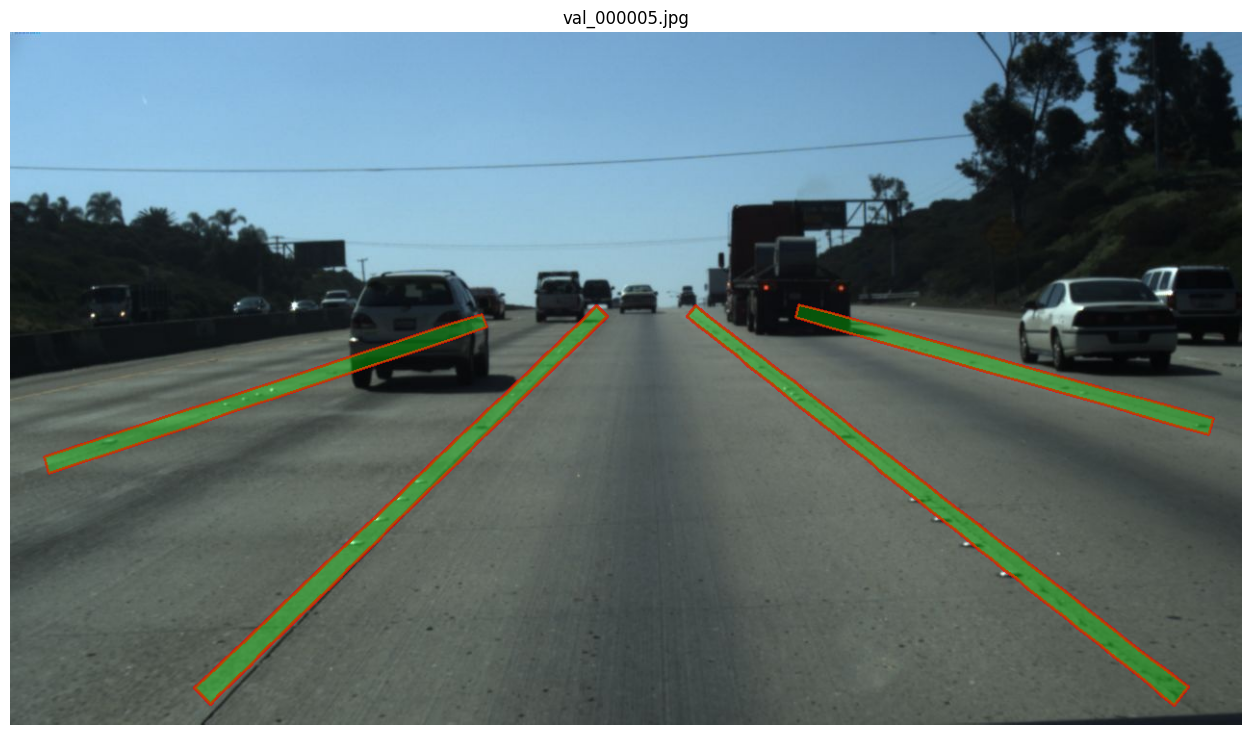

In [12]:
import cv2
import matplotlib.pyplot as plt

sample_img = sorted(glob.glob(f"{YOLO_DATASET}/images/val/*.jpg"))[5]
sample_lbl = sample_img.replace("/images/", "/labels/").replace(".jpg", ".txt")

img = cv2.cvtColor(cv2.imread(sample_img), cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
overlay = img.copy()

with open(sample_lbl) as f:
    for line in f:
        values = list(map(float, line.split()))
        pts = np.array(values[1:]).reshape(-1, 2)
        pts[:, 0] *= w
        pts[:, 1] *= h
        pts = pts.astype(np.int32)

        cv2.fillPoly(overlay, [pts], (0, 255, 0))
        cv2.polylines(img, [pts], True, (255, 0, 0), 2)

plt.figure(figsize=(16, 9))
plt.imshow(cv2.addWeighted(img, 0.7, overlay, 0.3, 0))
plt.axis("off")
plt.title(os.path.basename(sample_img))
plt.show()

## 8. Train

Notes on the non-default settings:

- `yolo11s-seg` — with ~2.9k training images the larger variants overfit
  before they out-earn the small one, and `x` at batch 4 takes 5+ hours on a
  T4, which outlasts a typical Colab session.
- `mosaic=0.0` — mosaic stitches four frames into one, creating lanes that
  terminate mid-air at the seams. Bad for thin continuous structures.
- `mask_ratio=2` — Ultralytics downsamples segmentation masks by 4 by
  default. A 10px-wide lane at 640px input becomes ~1px after that, which
  destroys the supervision signal. 2 keeps it trainable; 1 is sharper but
  uses more memory.
- `degrees` / `shear` / `perspective` at 0 — the camera is rigidly mounted,
  so rotated road geometry is off-distribution and only adds noise.
- `fliplr=0.5` is kept: a mirrored road is a plausible road.

If you hit CUDA OOM, drop `batch` to 8. `batch=-1` auto-tunes to ~60% VRAM.

In [13]:
model = YOLO("yolo11s-seg.pt")

results = model.train(
    data=YAML_PATH,
    epochs=60,
    imgsz=640,
    batch=16,
    workers=2,
    device=0,
    amp=True,
    optimizer="auto",
    patience=20,
    # augmentation
    mosaic=0.0,
    degrees=0.0,
    shear=0.0,
    perspective=0.0,
    fliplr=0.5,
    scale=0.4,
    translate=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    # segmentation
    mask_ratio=2,
    overlap_mask=True,
    # bookkeeping
    project=PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
    save=True,
    save_period=10,
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tusimple_yolo/tusimple.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=2, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolo11s_tusimple, nbs=64, nms=None, 

### If Colab disconnected mid-run

Re-run the setup cells above (through the YAML cell), then run this instead
of the training cell. It picks up from `last.pt` with the original settings.

In [14]:
# model = YOLO(f"{PROJECT_DIR}/{RUN_NAME}/weights/last.pt")
# results = model.train(resume=True)

## 9. Evaluate

In [15]:
best = f"{PROJECT_DIR}/{RUN_NAME}/weights/best.pt"
model = YOLO(best)

metrics = model.val(data=YAML_PATH, imgsz=640, batch=16, device=0)

print("Box  mAP50:", round(metrics.box.map50, 4))
print("Box  mAP50-95:", round(metrics.box.map, 4))
print("Mask mAP50:", round(metrics.seg.map50, 4))
print("Mask mAP50-95:", round(metrics.seg.map, 4))

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 113 layers, 10,067,203 parameters, 0 gradients, 32.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1997.0±627.1 MB/s, size: 157.8 KB)
val: Scanning /content/tusimple_yolo/labels/val.cache... 726 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 726/726 169.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 3.2it/s 14.2s
                   all        726       2732      0.976      0.974      0.992      0.831      0.925      0.923       0.89      0.389
Speed: 1.2ms preprocess, 8.1ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/segment/val
Box  mAP50: 0.9919
Box  mAP50-95: 0.8314
Mask mAP50: 0.8896
Mask mAP50-95: 0.3893


mAP here is measured against the synthetic ribbons, not against TuSimple's
official benchmark (point-wise accuracy / FP / FN at fixed `h_samples` rows).
It will read optimistically. Treat it as a training-progress signal, not as a
publishable number.

results.png


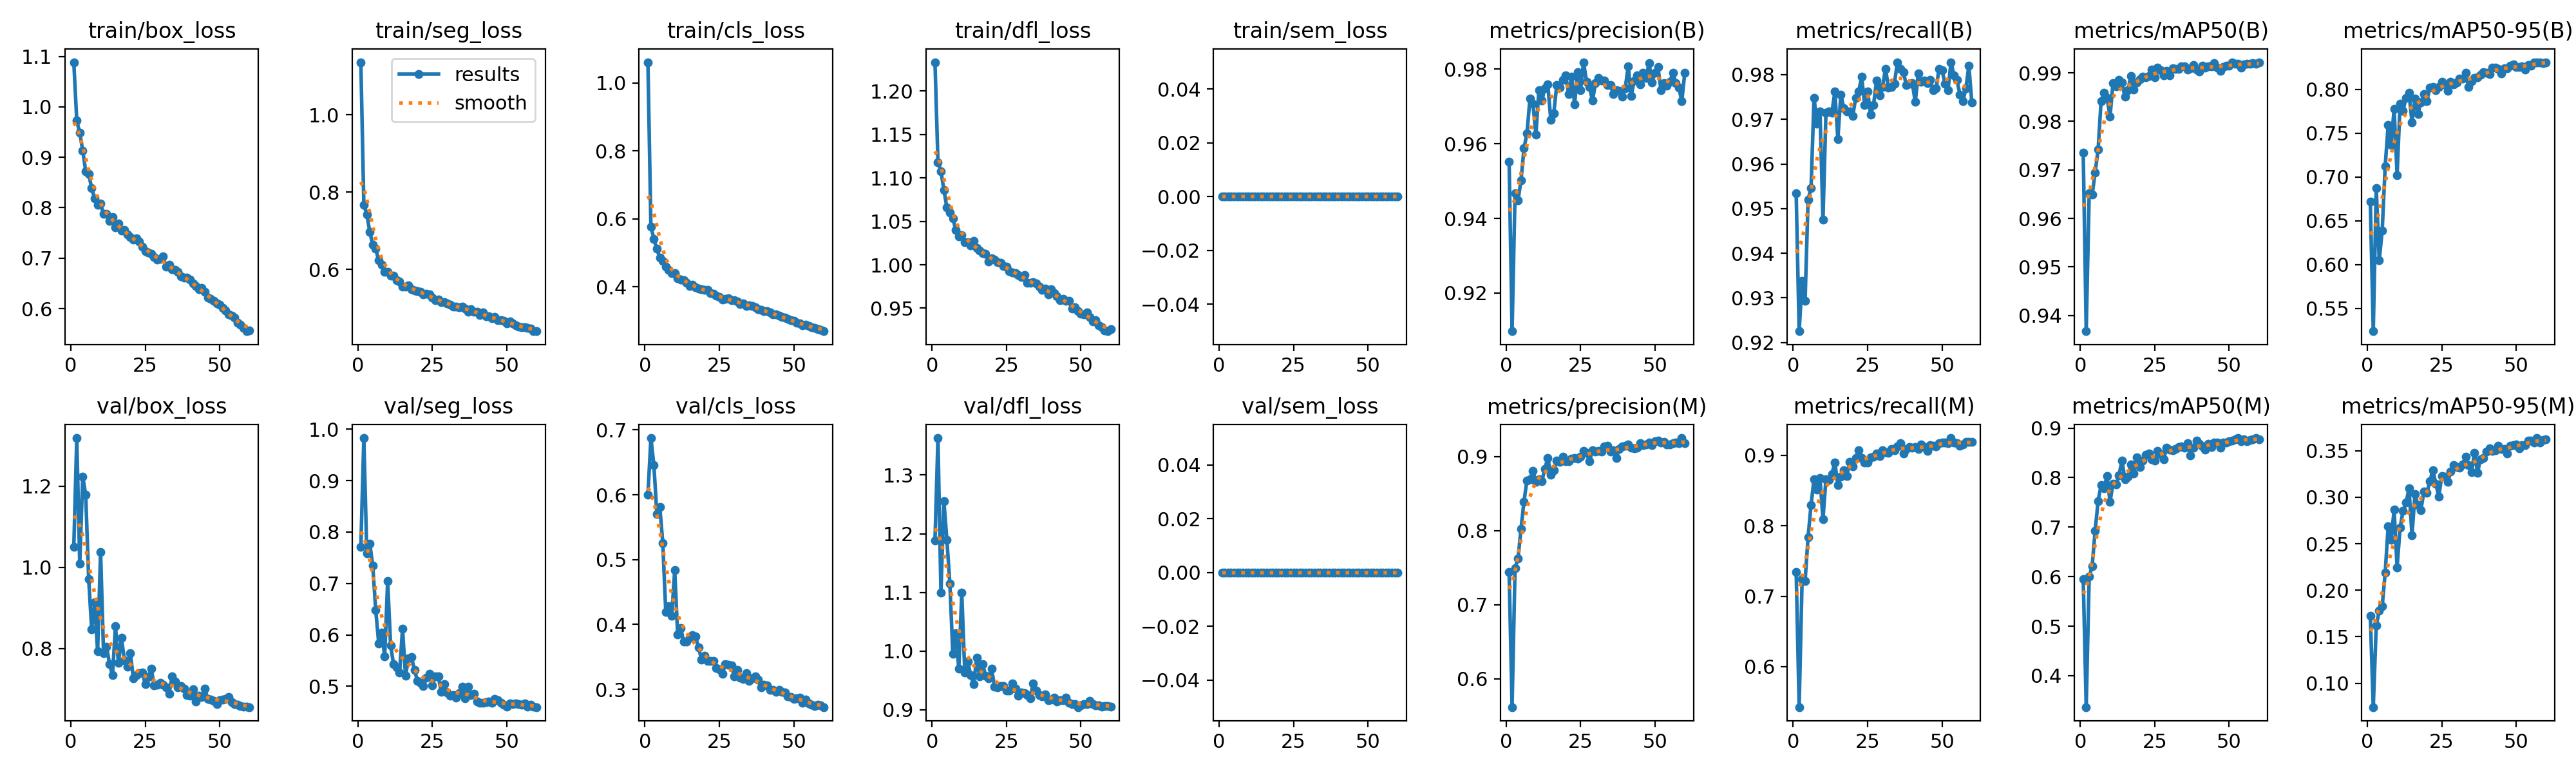

confusion_matrix.png


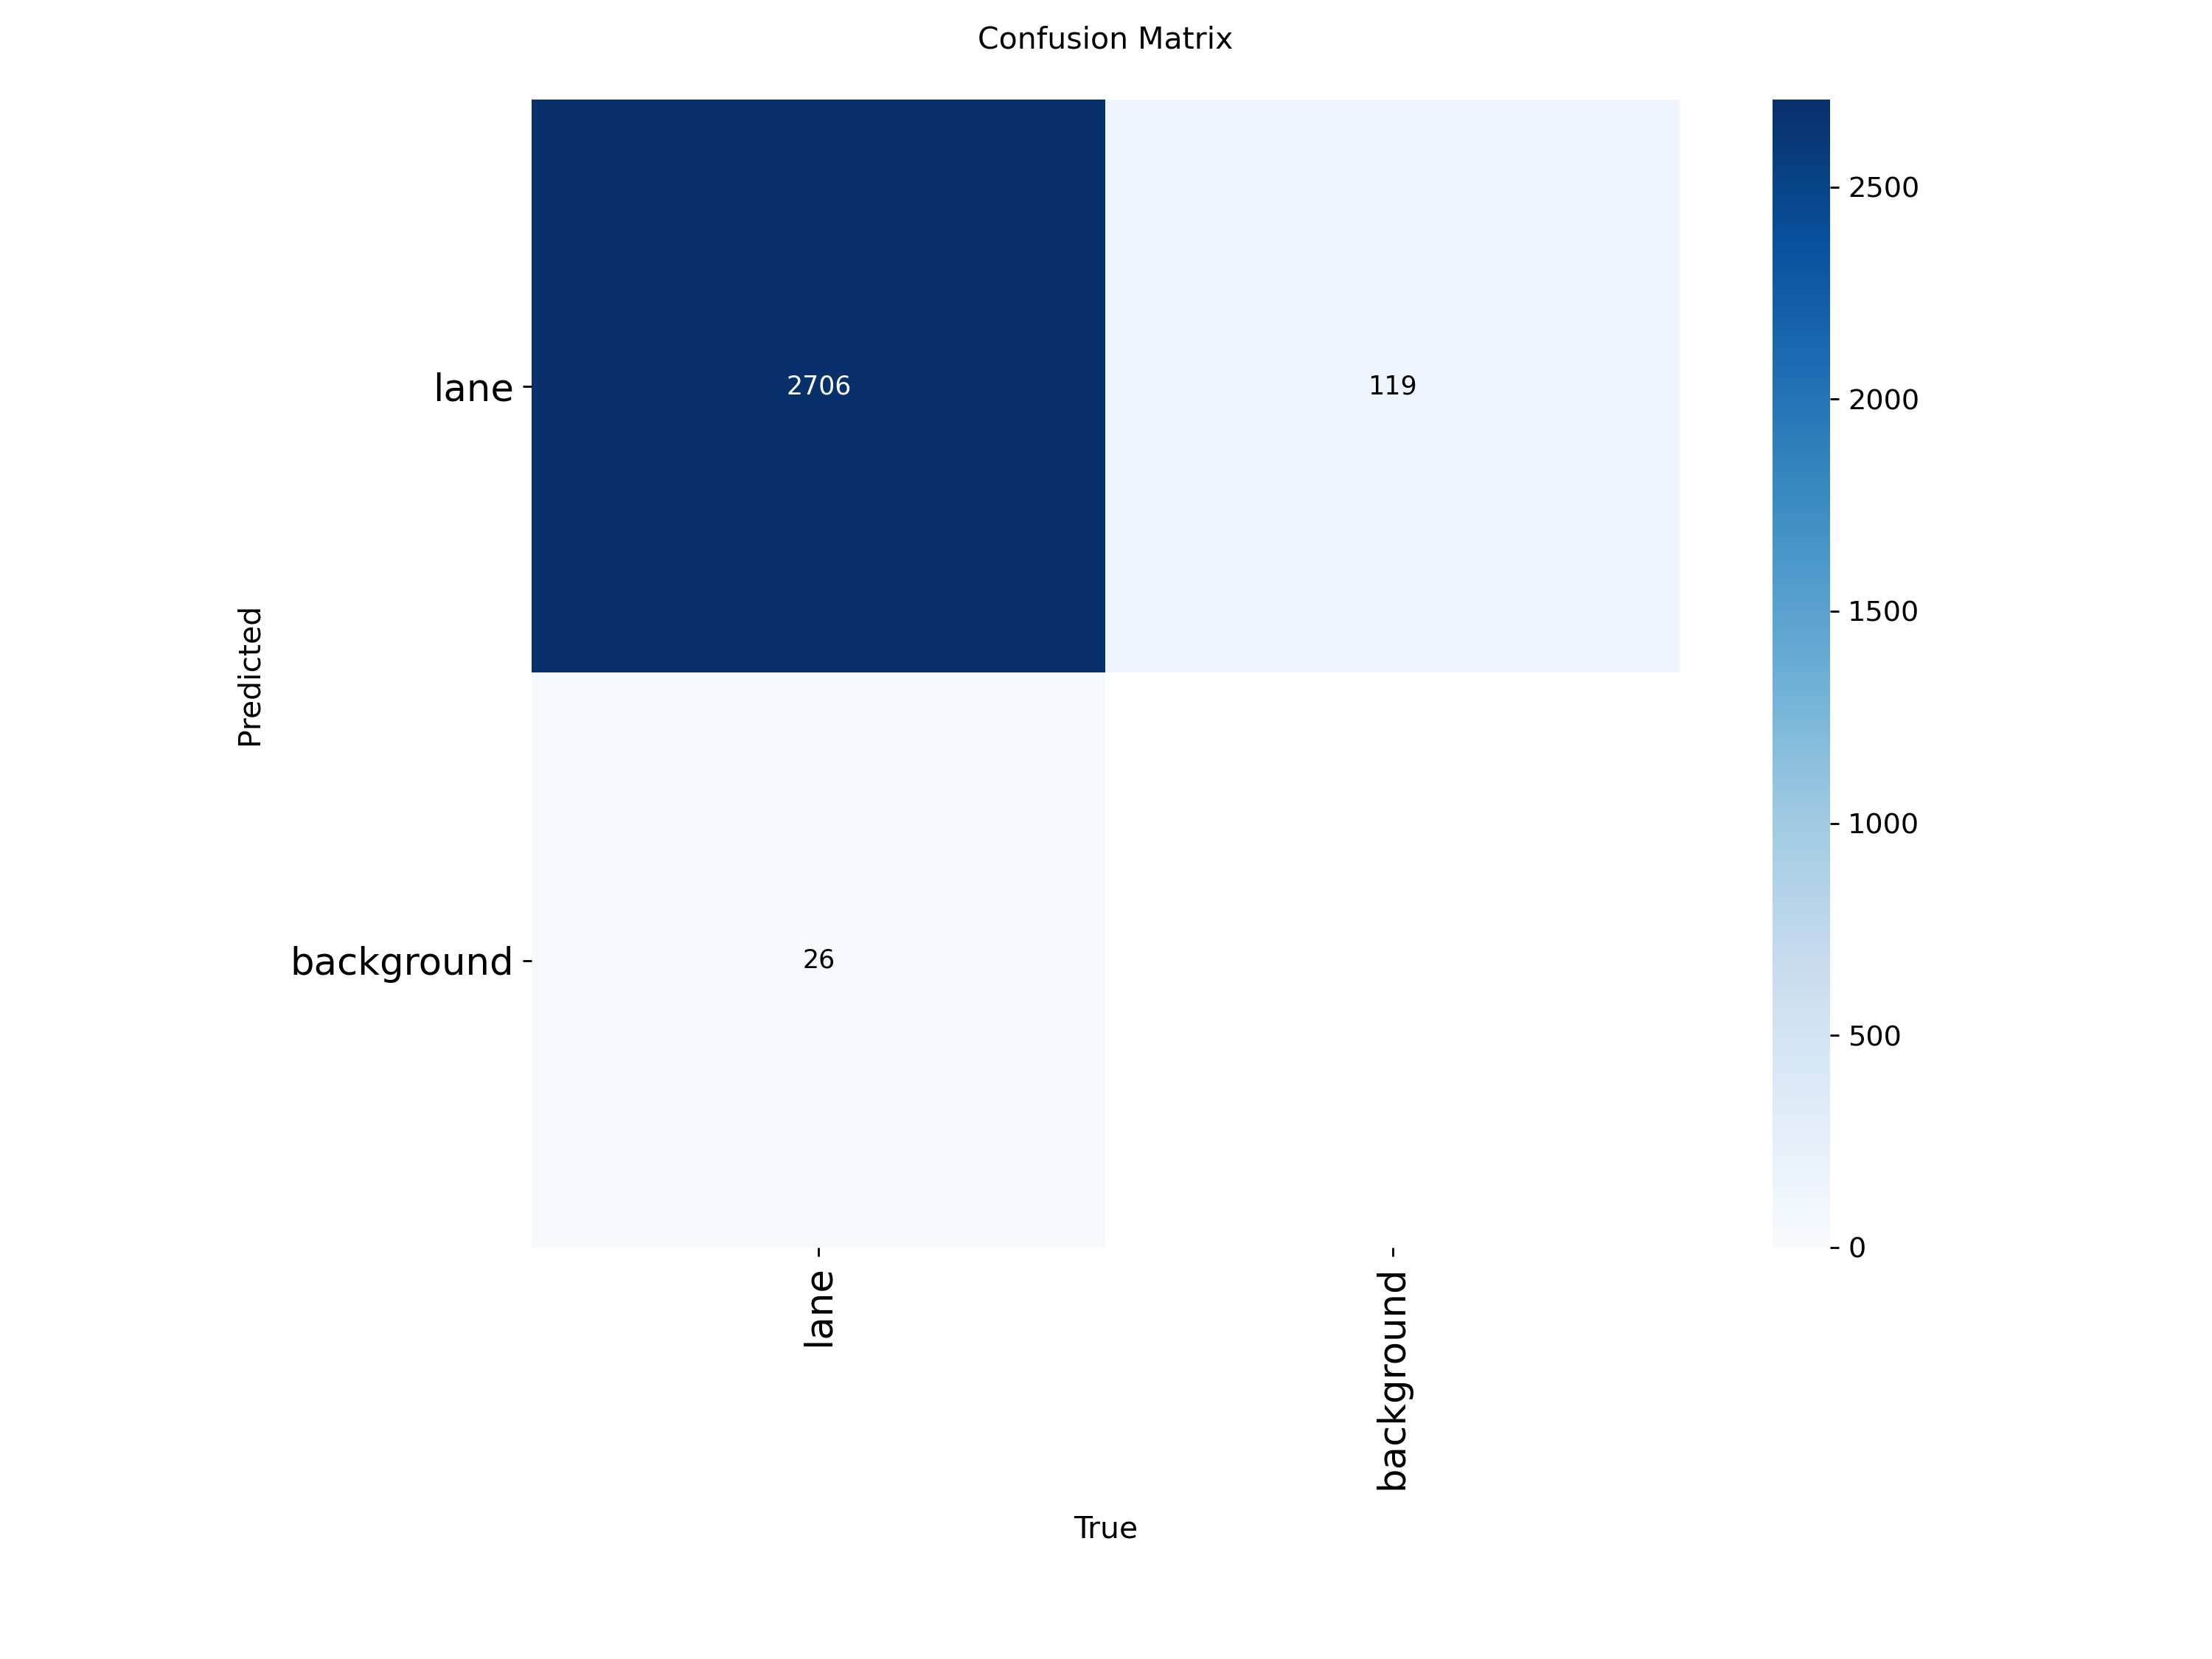

val_batch0_pred.jpg


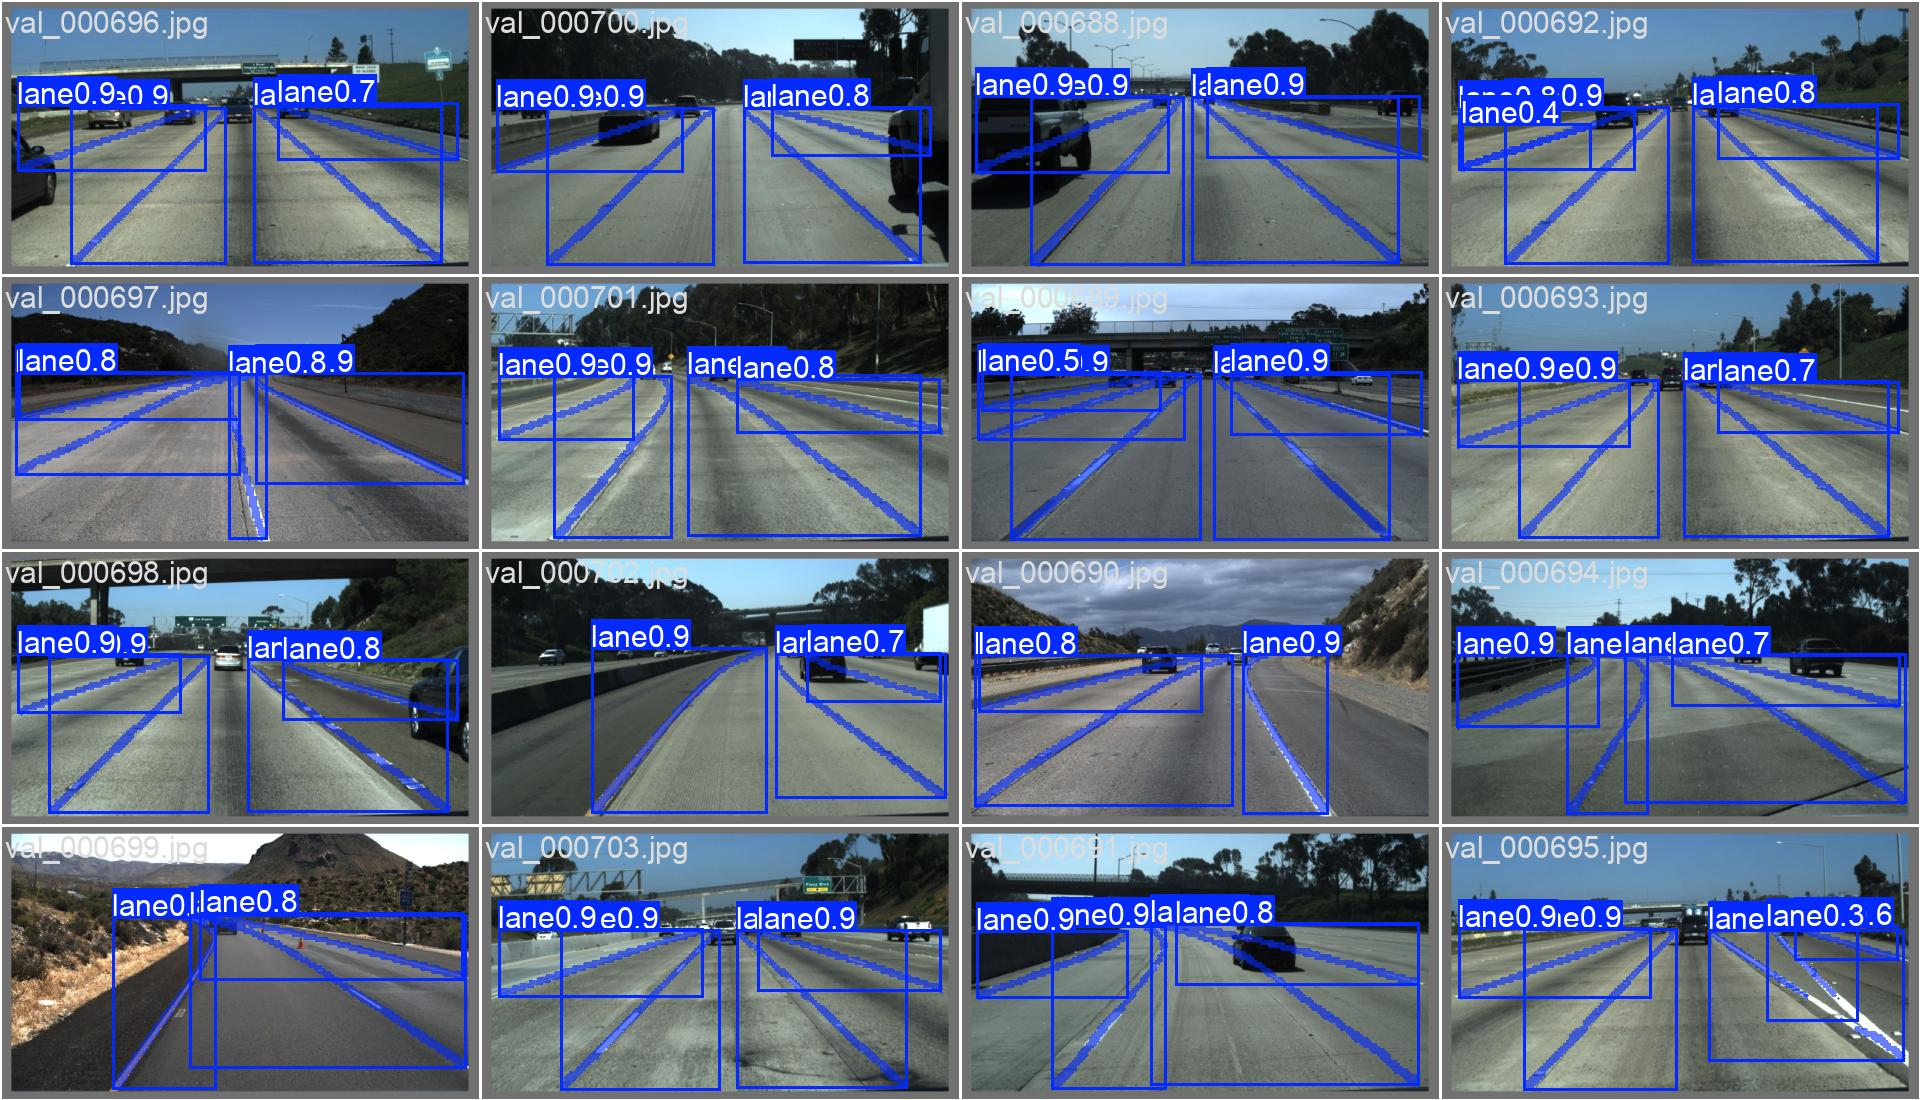

In [16]:
# Training curves and validation batch previews
from IPython.display import Image as IPyImage, display

for name in ["results.png", "confusion_matrix.png", "val_batch0_pred.jpg"]:
    path = f"{PROJECT_DIR}/{RUN_NAME}/{name}"
    if os.path.exists(path):
        print(name)
        display(IPyImage(filename=path, width=900))

## 10. Predict on held-out images


0: 384x640 3 lanes, 10.2ms
1: 384x640 3 lanes, 10.2ms
2: 384x640 4 lanes, 10.2ms
3: 384x640 3 lanes, 10.2ms
4: 384x640 4 lanes, 10.2ms
5: 384x640 4 lanes, 10.2ms
Speed: 1.1ms preprocess, 10.2ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)


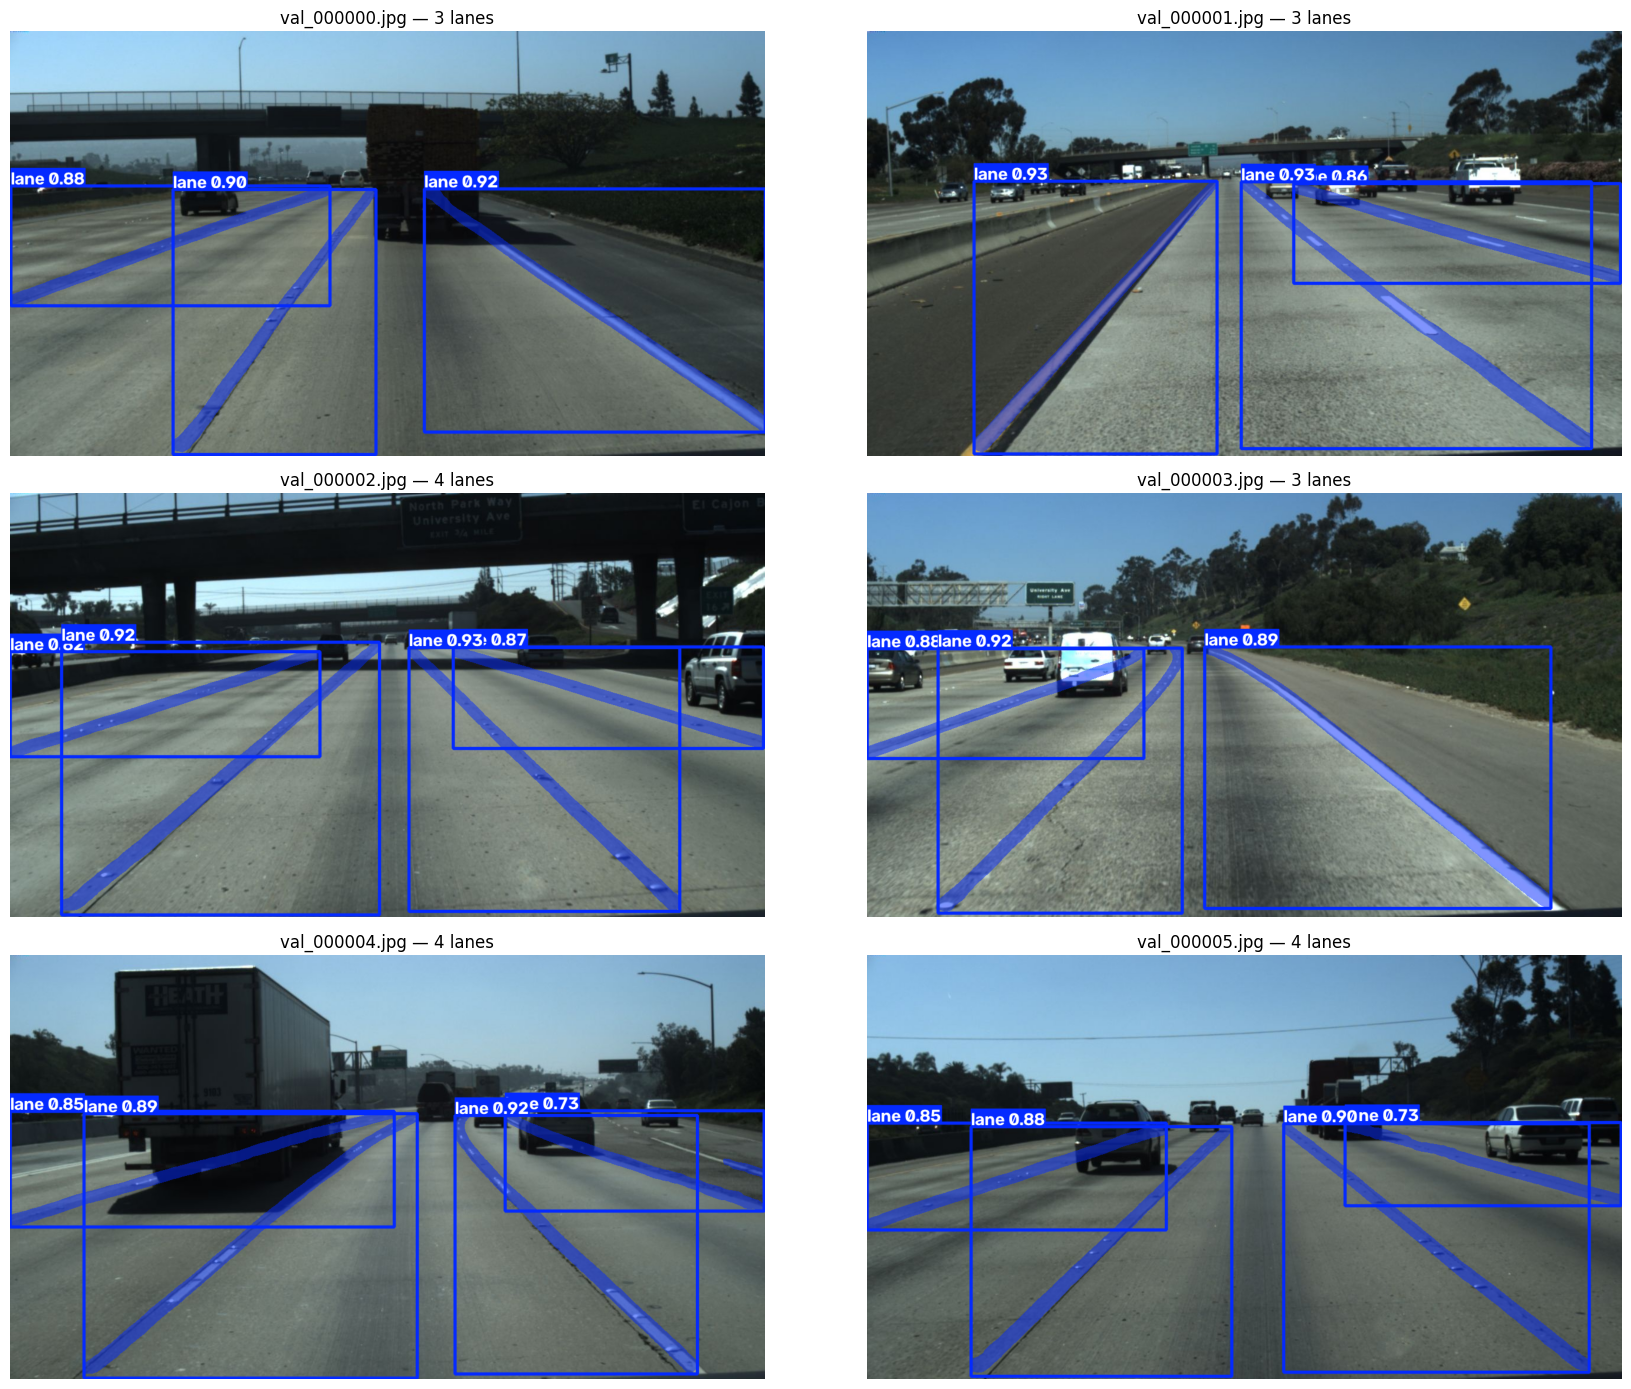

In [17]:
val_images = sorted(glob.glob(f"{YOLO_DATASET}/images/val/*.jpg"))[:6]

preds = model.predict(
    val_images,
    imgsz=640,
    conf=0.25,
    device=0,
    retina_masks=True,
    save=False,
)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

for ax, pred in zip(axes.ravel(), preds):
    ax.imshow(cv2.cvtColor(pred.plot(), cv2.COLOR_BGR2RGB))
    n = 0 if pred.masks is None else len(pred.masks)
    ax.set_title(f"{os.path.basename(pred.path)} — {n} lanes")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Export the weights

`best.pt` is already on Drive at
`lane_detection/yolo11s_tusimple/weights/best.pt`. ONNX is useful if you plan
to run inference outside PyTorch.

In [18]:
# model.export(format="onnx", imgsz=640, simplify=True)